<a href="https://colab.research.google.com/github/kyliequinney/DataScience4372/blob/main/4372Assignment5/4372_asgmt5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Natalie Pedigo (nbp220000),
Kylie Quinney (krq210000)

In [ ]:
!pip install mplfinance
!pip install yfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 1.9 MB/s eta 0:00:00


In [ ]:
!wget http://prdownloads.sourceforge.net/ta-lib/ta-lib-0.4.0-src.tar.gz
!tar -xzvf ta-lib-0.4.0-src.tar.gz
%cd ta-lib
!./configure --prefix=/usr --silent
!make --silent
!make install --silent
!pip install Ta-Lib
import talib

--2024-12-01 21:47:19--  http://prdownloads.sourceforge.net/ta-lib/ta-lib-0.4.0-src.tar.gz
Resolving prdownloads.sourceforge.net (prdownloads.sourceforge.net)... 104.18.13.149, 104.18.12.149, 2606:4700::6812:c95, ...
Connecting to prdownloads.sourceforge.net (prdownloads.sourceforge.net)|104.18.13.149|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: http://downloads.sourceforge.net/project/ta-lib/ta-lib/0.4.0/ta-lib-0.4.0-src.tar.gz [following]
--2024-12-01 21:47:19--  http://downloads.sourceforge.net/project/ta-lib/ta-lib/0.4.0/ta-lib-0.4.0-src.tar.gz
Resolving downloads.sourceforge.net (downloads.sourceforge.net)... 104.18.13.149, 104.18.12.149, 2606:4700::6812:c95, ...
Reusing existing connection to prdownloads.sourceforge.net:80.
HTTP request sent, awaiting response... 302 Found
Location: http://nchc.dl.sourceforge.net/project/ta-lib/ta-lib/0.4.0/ta-lib-0.4.0-src.tar.gz?viasf=1 [following]
--2024-12-01 21:47:19--  http://nchc.dl.sourceforge.

In [ ]:
from datetime import datetime, timedelta
import pandas as pd
import yfinance as yf
import mplfinance as mpf
from datetime import datetime, timedelta
import mplfinance as mpf
import talib as talib
import seaborn as sns
import matplotlib.pyplot as plt


1. Buy and Hold: In this strategy, you invest $1,000 every month into a stock of your
choice and hold the investment till the expiry of the test period (30 years by
default). You do not care whether the market is going up or down but invest
consistently the same fixed amount.

[*********************100%***********************]  1 of 1 completed


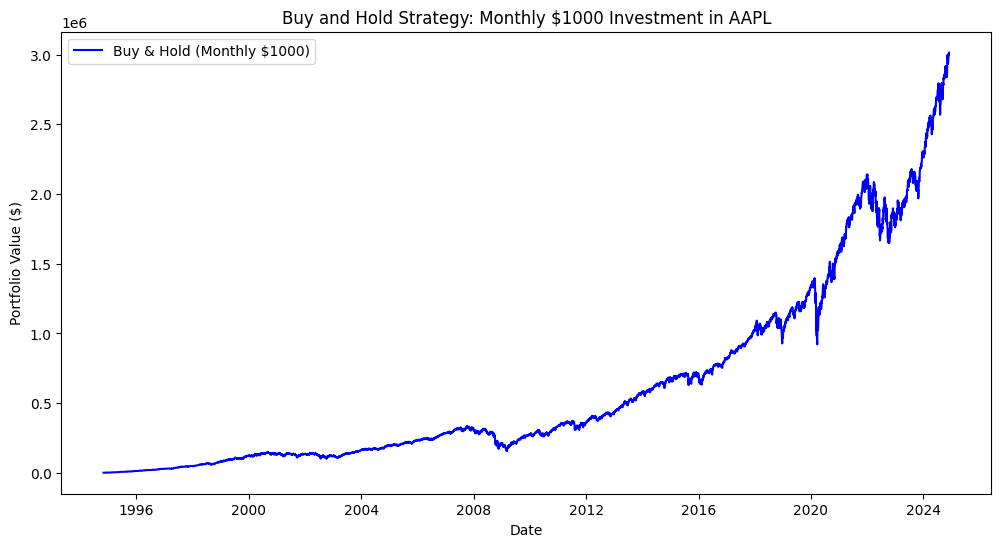

Price,Adj Close,Close,High,Low,Open,Volume,returns,Total_Investment,Buy_and_Hold
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC,,,
Date,,,,,,,,,
1994-11-01 00:00:00+00:00,468.420013,468.420013,472.260010,467.640015,472.260010,314940000,NaN,1000,1000.000000
1994-11-02 00:00:00+00:00,466.510010,466.510010,470.920013,466.359985,468.410004,331360000,-0.004078,1000,995.922455
1994-11-03 00:00:00+00:00,467.910004,467.910004,468.640015,466.399994,466.500000,285170000,0.003001,1000,998.911213
1994-11-04 00:00:00+00:00,462.279999,462.279999,469.279999,462.279999,467.959991,280560000,-0.012032,1000,986.892074
1994-11-07 00:00:00+00:00,463.070007,463.070007,463.559998,461.250000,462.309998,255030000,0.001709,1000,988.578613
1994-11-08 00:00:00+00:00,465.649994,465.649994,467.540009,463.070007,463.079987,290860000,0.005571,1000,994.086462
1994-11-09 00:00:00+00:00,465.399994,465.399994,469.950012,463.459991,465.649994,337780000,-0.000537,1000,993.552753
1994-11-10 00:00:00+00:00,464.369995,464.369995,467.790009,463.730011,465.399994,280910000,-0.002213,1000,991.353874


In [ ]:
# get data
#use s&P 500 as stock
ticker_symbol = '^GSPC'
#ticker_symbol = 'AAPL'

df = yf.download(ticker_symbol, start='1994-11-01' )
df['returns'] = df['Adj Close'].pct_change()
monthly_investment = 1000
total_investment = 0

df['Total_Investment'] = 0
df['Buy_and_Hold'] = 0.0

for i in range(0, len(df)):
    if df.index[i].day == 1:
        total_investment += monthly_investment
    df.loc[df.index[i], 'Total_Investment'] = total_investment
    df.loc[df.index[i], 'Buy_and_Hold'] = total_investment * (1 + df['returns'].iloc[:i+1]).prod()

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Buy_and_Hold'], label="Buy & Hold (Monthly $1000)", color='blue')
plt.title('Buy and Hold Strategy: Monthly $1000 Investment in S&P 500')
plt.xlabel('Date')
plt.ylabel('Portfolio Value ($)')
plt.legend()
plt.show()

df.head(10)

In [ ]:
total_equity_at_end = df['Buy_and_Hold'].iloc[-1]
print(f"Total equity after 30 Years: ${total_equity_at_end:,.2f}")
initial_investment_value = monthly_investment

years_invested = (df.index[-1] - df.index[0]).days / 365.25

#Compound Annual Growth Rate (CAGR)
CAGR = (total_equity_at_end / initial_investment_value) ** (1 / years_invested) - 1
annual_percent_return = CAGR * 100
print(f"Annual Percent Return (CAGR): {annual_percent_return:.2f}%")


Total equity after 30 Years: $3,013,485.44
Annual Percent Return (CAGR): 30.52%


2. Active Trading

In [ ]:
# SMA crossover parameters
short_window = 50
long_window = 200

# calculate SMAs
df['SMA_short'] = df['Adj Close'].rolling(window=short_window, min_periods =1).mean()
df['SMA_long'] = df['Adj Close'].rolling(window=long_window, min_periods = 1).mean()

In [ ]:
df['Signal'] = 0
df.loc[df['SMA_short'] > df['SMA_long'], 'Signal'] = 1 # buy signal
df.loc[df['SMA_short'] < df['SMA_long'], 'Signal'] = -1 # sell signal

In [ ]:
# generate buy/sell signals
df['Signal'] = 0
df.loc[df['SMA_short'] > df['SMA_long'], 'Signal'] = 1
df.loc[df['SMA_short'] < df['SMA_long'], 'Signal'] = -1

In [ ]:
# simulate trading strategy
initial_investment = 0
savings_account = 0
stock_market_value = 0
total_equity = []
monthly_dates = []

for Date, row in df.iterrows():
  if pd.isna(row['Signal']).any():
    continue


  date_object = df.index[df.index == Date][0]


  if row['Signal'].item() == 1:
    if initial_investment == 0:
      initial_investment = 1000
      savings_account = 0
      stock_market_value += 1000 #invest 1000

  elif row['Signal'].item() == -1:
    if initial_investment > 0:
      savings_account += stock_market_value
      stock_market_value = 0
    savings_account += 1000

  #calculate total equity
  total_equity.append(savings_account + stock_market_value)


In [ ]:
#calculate final metrics
final_equity = total_equity[-1]
print(f"Total equity after 30 Years: ${final_equity:,.2f}")

annual_return = ((final_equity / initial_investment) ** (1 / 30) - 1) * 100 if initial_investment > 0 else 0
print(f"Annual Return: {annual_return:.2f}%")


Total equity after 30 Years: $1,877,000.00
Annual Return: 28.56%


In [ ]:
# add column in table for active trading strategy equity
df['Active_Trading'] = total_equity

In [ ]:
df.tail()

Price,Adj Close,Close,High,Low,Open,Volume,returns,Total_Investment,Buy_and_Hold,SMA_short,SMA_long,Signal,Active_Trading
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC,,,,,,,
Date,,,,,,,,,,,,,
2024-11-22 00:00:00+00:00,5969.339844,5969.339844,5972.899902,5944.359863,5944.359863,4141420000,0.003468,234000,2.981994e+06,5810.068975,5434.984592,1,1877000
2024-11-25 00:00:00+00:00,5987.370117,5987.370117,6020.750000,5963.910156,5992.279785,5633150000,0.003020,234000,2.991001e+06,5817.154580,5439.788394,1,1877000
2024-11-26 00:00:00+00:00,6021.629883,6021.629883,6025.419922,5992.270020,6000.029785,3835170000,0.005722,234000,3.008115e+06,5824.895576,5444.787344,1,1877000
2024-11-27 00:00:00+00:00,5998.740234,5998.740234,6020.160156,5984.870117,6014.109863,3363340000,-0.003801,234000,2.996681e+06,5832.505186,5450.015195,1,1877000
2024-11-29 00:00:00+00:00,6032.379883,6032.379883,6044.169922,6003.979980,6003.979980,2444420000,0.005608,234000,3.013485e+06,5838.879980,5455.173994,1,1877000


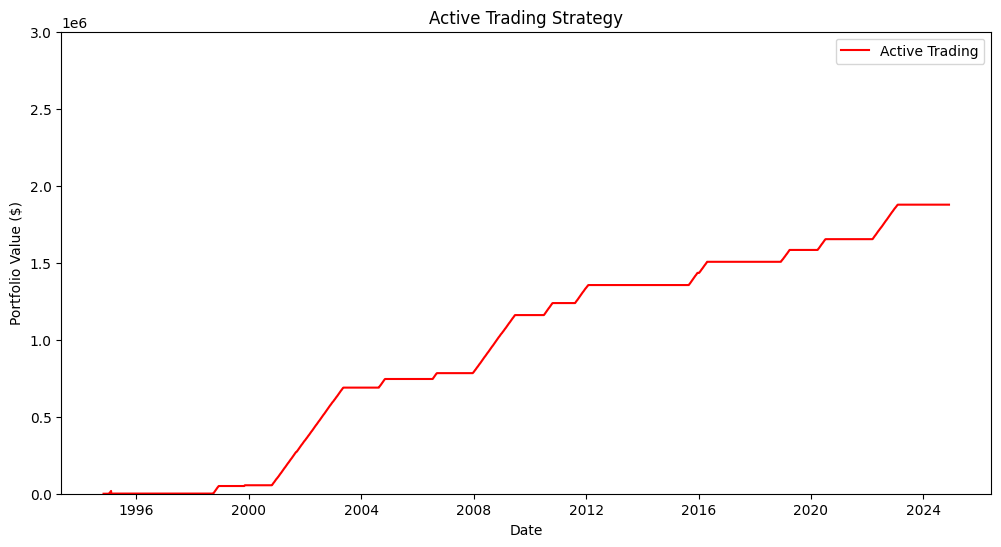

In [ ]:
#make y axis range from 0-3
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Active_Trading'], label="Active Trading", color='red')
plt.title('Active Trading Strategy')
plt.xlabel('Date')
plt.ylabel('Portfolio Value ($)')
plt.legend()
plt.ylim(0, 3e6)
plt.show()

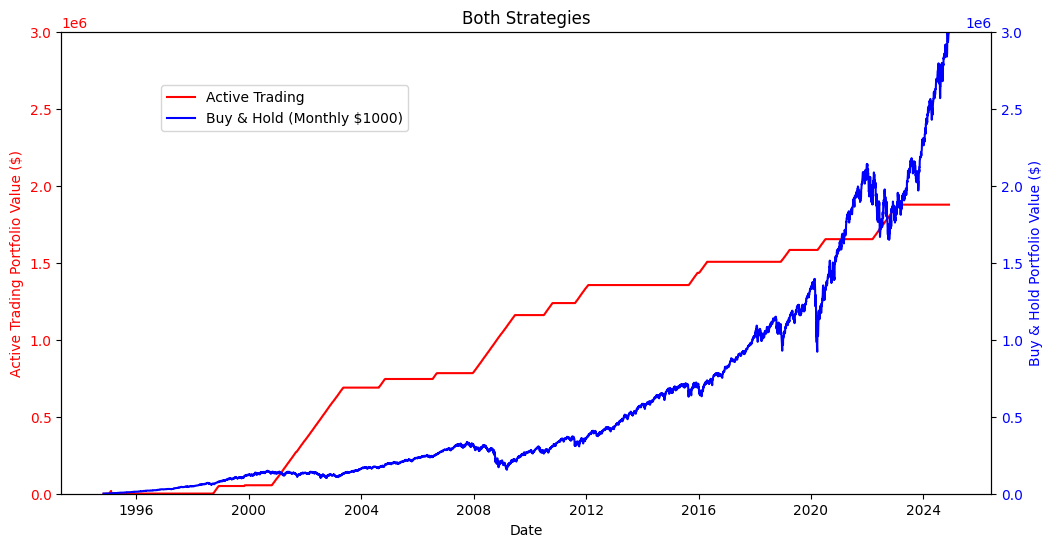

In [ ]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Active Trading on the left y-axis
ax1.plot(df.index, df['Active_Trading'], label="Active Trading", color='red')
ax1.set_ylabel('Active Trading Portfolio Value ($)', color='red')
ax1.tick_params(axis='y', labelcolor='red')
ax1.set_ylim(0, 3e6)  # Scale slightly above max for better visualization

# Create a second y-axis for Buy & Hold
ax2 = ax1.twinx()
ax2.plot(df.index, df['Buy_and_Hold'], label="Buy & Hold (Monthly $1000)", color='blue')
ax2.set_ylabel('Buy & Hold Portfolio Value ($)', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')
ax2.set_ylim(0, 3e6)

# Title and shared x-axis
plt.title('Both Strategies')
ax1.set_xlabel('Date')

# Combine legends from both axes
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9), bbox_transform=ax1.transAxes)

plt.show()
